
# Rotating point source

Demonstrates the use of acoular for a point source moving on a circle trajectory.
Uses synthesized data.

Four different methods are compared:

* fixed focus time domain beamforming
* fixed focus frequency domain beamforming
* moving focus time domain beamforming
* moving focus time domain deconvolution


In [3]:
import acoular as ac
import numpy as np

First, we make some important definitions:

* the frequency of interest (114 Hz),
* 1/3 octave band for later analysis,
* the sampling frequency (3072 Hz),
* the array radius (3.0),
* the radius of the source trajectory (2.5),
* the distance of the source trajectory from the array (4),
* the revolutions per second (15/60),
* the total number of revolutions (1.5).



In [4]:
freq = 6144.0 * 3 / 128.0
num = 3
sfreq = 6144.0 / 2
r = 3.0
R = 2.5
Z = 4
rps = 15.0 / 60.0
U = 1.5

Construct the trajectory for the source. The source moves on a circle trajectory in
anti-clockwise direction.



In [5]:
tr = ac.Trajectory()
tr1 = ac.Trajectory()
tmax = U / rps
delta_t = 1.0 / rps / 16.0  # 16 steps per revolution
for t in np.arange(0, tmax * 1.001, delta_t):
    i = t * rps * 2 * np.pi  # angle
    # define points for trajectory spline
    tr.points[t] = (R * np.cos(i), R * np.sin(i), Z)  # anti-clockwise rotation
    tr1.points[t] = (R * np.cos(i), R * np.sin(i), Z)  # anti-clockwise rotation

Define a circular microphone array with 28 microphones.



In [6]:
m = ac.MicGeom()
m.mpos_tot = np.array(
    [
        (r * np.sin(2 * np.pi * i + np.pi / 4), r * np.cos(2 * np.pi * i + np.pi / 4), 0)
        for i in np.linspace(0.0, 1.0, 28, False)
    ],
).T

Define the different source signals



In [7]:
nsamples = int(sfreq * tmax)
n1 = ac.WNoiseGenerator(sample_freq=sfreq, numsamples=nsamples)
s1 = ac.SineGenerator(sample_freq=sfreq, numsamples=nsamples, freq=freq)

Define the moving source and one fixed source and mix their signals.
The simulation output is cached by the :class:`~acoular.process.Cache` class.



In [8]:
p0 = ac.MovingPointSource(signal=s1, mics=m, trajectory=tr1)
p1 = ac.PointSource(signal=n1, mics=m, loc=(0, R, Z))
t = ac.Mixer(source=p1, sources=[p0])
# t = p0 # use only moving source
# t = p1 # use only fix source
cached_mix = ac.Cache(source=t)


Optionally, save the signal of channel 0 and 14 to a wave file.



In [19]:
# ww = WriteWAV(source = t)
# ww.channels = [0,14]
# ww.save()

Define the evaluation grid and the steering vector.



In [9]:
g = ac.RectGrid(x_min=-3.0, x_max=+3.0, y_min=-3.0, y_max=+3.0, z=Z, increment=0.3)
st = ac.SteeringVector(grid=g, mics=m)

## Fixed focus time domain beamforming



In [58]:
fi = ac.FiltFiltOctave(source=cached_mix, band=freq, fraction='Third octave')
bt = ac.BeamformerTimeSq(source=fi, steer=st, r_diag=True)
print(int(sfreq * tmax / 144))
avgt = ac.Average(source=bt, naverage=128)  # 32 single images
cacht = ac.Cache(source=avgt)  # cache to prevent recalculation

128


Plot single frames



In [ ]:
from pylab import axis, colorbar, figure, imshow, show, subplot, text, tight_layout, title, transpose

figure(1, (8, 16))
i = 1
for res in cacht.result(1):
    res0 = res[0].reshape(g.shape)
    i += 1
    subplot(8, 4, i)
    mx = ac.L_p(res0.max())
    imshow(ac.L_p(transpose(res0)), vmax=mx, vmin=mx - 10, interpolation='nearest', extent=g.extend(), origin='lower')

subplot(8, 4, 1)
text(0.4, 0.25, 'fixed\nfocus', fontsize=15, ha='center')
axis('off')
tight_layout()

In [ ]:
l = list(cacht.result(1))
i = 1
for res in l:
    print(res)
    # res0 = res[0].reshape(g.shape)
    # i += 1
    # print("hello", i)
    # print(res0)

[('void_cache.h5', 12)]
Video saved as 'output_video.mp4'


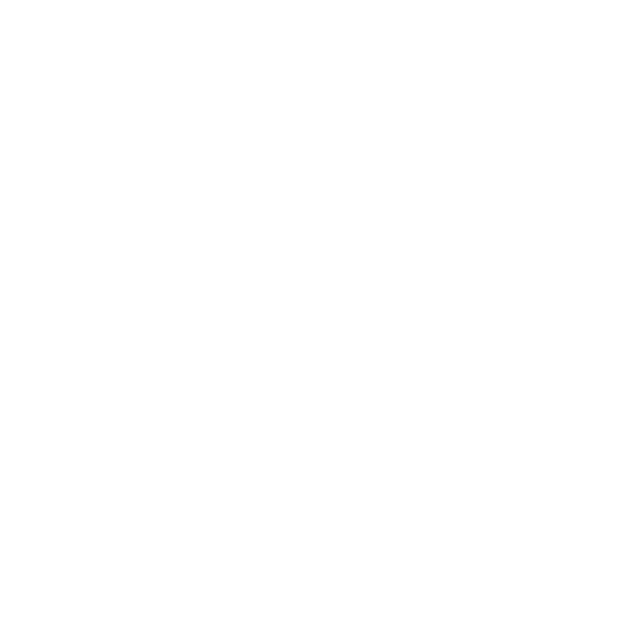

In [59]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Create figure for animation
fig, ax = plt.subplots(figsize=(8, 8))


def init():
    ax.clear()
    ax.axis("off")

# Animation function
def update(frame):
    res = np.array(frame[0]).reshape(g.shape)
    mx = ac.L_p(res.max())
    ax.clear()  # Clear previous plot
    ax.imshow(
        ac.L_p(np.transpose(res)),
        vmax=mx,
        vmin=mx - 10,
        interpolation="nearest",
        extent=g.extend(),
        origin="lower",
    )
    ax.set_title(f"Frame {i}")


# Prepare frames
frames = list(cacht.result(1))

ani = animation.FuncAnimation(fig, update, frames=frames, init_func=init, repeat=False)

# Save as video
ani.save("output_video.mp4", writer="ffmpeg", fps=24)  # Adjust FPS as needed

print("Video saved as 'output_video.mp4'")